# pyspi tutorial

### MDIG 2026 Summer School Workshop
### Author: Annie G. Bryant, PhD

A hands-on tour of [`pyspi`](https://github.com/DynamicsAndNeuralSystems/pyspi) (Python-based Statistics for Pairwise Interactions), applied to real motion-tracking data from a dyadic interaction task. Starting from a single pair of time series and a single statistic, we build up through five levels of analysis:

1. **Level 1** — one pair of time series (hip sway), one statistic (covariance), computed by hand
2. **Level 2** — the same pair, now compared with the `sonnet` SPI subset (14 statistics)
3. **Level 3** — the same pair, compared with the `fast` SPI subset
4. **Level 4** — the `sonnet` subset applied across four distinct body-part pairs
5. **Level 5** — a 4-node multivariate system (both hips and both noses), analysed jointly

We close with a short extension to real resting-state fMRI data, to show the same pipeline scales from motion capture to brain imaging.

## Setup

Let's start by (1) installing the required packages for this tutorial, and (2) importing them.

In [ ]:
# Install octave
!apt update
!apt install -y octave

!pip install pyspi pandas matplotlib rpy2 oct2py

# We need a specific version of spectral_connectivity
!pip install "spectral_connectivity<2.0"

# And numpy
!pip install "numpy<=2.4"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import scipy
from copy import deepcopy

# pyspi-specific imports 
from pyspi.calculator import Calculator
from pyspi.data import Data
from pyspi.statistics.basic import Covariance, CrossCorrelation
from pyspi.statistics.infotheory import DirectedInfo

# Add rpy2 to run R code chunks
%load_ext rpy2.ipython

We'll also bring in R via `rpy2`, so that later in the notebook we can hand off long-format results to `ggplot2`/`cowplot` for plotting. The cell below loads those R packages and sets `theme_cowplot()` as the default `ggplot2` theme.

In [2]:
%%R 

install.packages(c("cowplot", "tidyverse", "ggseg", "patchwork"), repos = "http://cran.us.r-project.org")

suppressPackageStartupMessages({
    library(cowplot)
    library(ggseg)
    library(ggseg.formats)
    library(patchwork)
    library(tidyverse)
})

# Set cowplot theme
theme_set(theme_cowplot())


The downloaded binary packages are in
	/var/folders/rn/z0683sns3tz7b_k0cbf8ft8w0000gq/T//RtmpYA5M0q/downloaded_packages


Installing packages into ‘/Users/abry4213/Library/R/arm64/4.5/library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/cowplot_1.2.0.tgz'
trying URL 'http://cran.us.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/tidyverse_2.0.0.tgz'
trying URL 'http://cran.us.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/ggseg_2.2.1.tgz'
trying URL 'http://cran.us.r-project.org/bin/macosx/big-sur-arm64/contrib/4.5/patchwork_1.3.2.tgz'


## Loading the example data

Now we can load in and view the example data for this tutorial: motion-tracking time series from a single trial of a dyadic guessing game, in which one participant (the clue-giver) silently acts out a word for the other (the guesser) to identify. Body landmark coordinates were tracked separately for each participant, as described in [Li et al. *JASA* (2026)](https://doi.org/10.1121/10.0043950).

Specifically, in this set of exercises, we will work with Participant 103 as the clue-giver and Participant 203 as the guesser, with the word 'balloon' as the target word in the Taboo game.

In [3]:
# Time series example datasets: Body tracking data of clue-giver versus guesser with the word 'balloon'
clue_giver_body_TS = pd.read_csv('https://github.com/WimPouw/TilburgMultiscaleSummerschool2026/raw/refs/heads/main/Datasets/BalanceCorpus/motiontracking/Output_TimeSeries/103_203_14_1_20250113_152536_balloon_board_clueGiver_cam01_body.csv')
guesser_body_TS = pd.read_csv('https://github.com/WimPouw/TilburgMultiscaleSummerschool2026/raw/refs/heads/main/Datasets/BalanceCorpus/motiontracking/Output_TimeSeries/103_203_14_1_20250113_152536_balloon_board_guesser_cam01_body.csv')

# Print size of the datasets
print(f"Clue-giver body time series shape: {clue_giver_body_TS.shape}")
print(f"Guesser body time series shape: {guesser_body_TS.shape}")

Clue-giver body time series shape: (663, 133)
Guesser body time series shape: (663, 133)


## Level 1: Hip time series for clue-giver versus guesser

We'll begin with the simplest possible case: a single pair of time series, compared with a single statistic. The signal of interest is *hip sway*, the average x-coordinate of the left and right hip landmarks, compared between the clue-giver and the guesser.

In [4]:
clue_giver_hip_TS = (clue_giver_body_TS["X_LEFT_HIP"] + clue_giver_body_TS["X_RIGHT_HIP"]) / 2
guesser_hip_TS = (guesser_body_TS["X_LEFT_HIP"] + guesser_body_TS["X_RIGHT_HIP"]) / 2

# Manually apply linear detrending and z-scoring to the time series, 
# only for visualization purposes (this is applied separately in pyspi)
clue_giver_hip_TS_detrend = scipy.stats.zscore(scipy.signal.detrend(clue_giver_hip_TS))
guesser_hip_TS_detrend = scipy.stats.zscore(scipy.signal.detrend(guesser_hip_TS))

# Combine the two time series into a two-column array
both_hip_TS = pd.DataFrame({
    'Clue-giver': clue_giver_hip_TS_detrend,
    'Guesser': guesser_hip_TS_detrend
})

both_hip_TS.head()


,Clue-giver,Guesser
0,0.422433,-2.556808
1,0.250746,-2.459046
2,0.189964,-2.382114
3,0.178308,-2.316100
4,0.171072,-2.166736


Plotting the two detrended, z-scored series together shows how closely the clue-giver's and guesser's hip sway track each other over the course of the trial.

<Figure size 640x480 with 0 Axes>

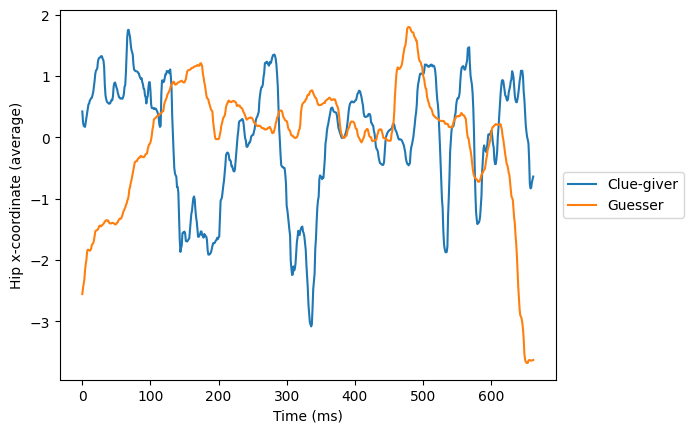

In [5]:
# Plot the time series
plt.figure()
both_hip_TS.plot()

ax = plt.gca()
ax.legend(labels=['Clue-giver', 'Guesser'], loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('Time (ms)')
plt.ylabel('Hip x-coordinate (average)')
plt.show()

A scatterplot of the same two series gives a complementary view: the tighter and more linear the cloud of points, the stronger the (linear) association between the two signals.

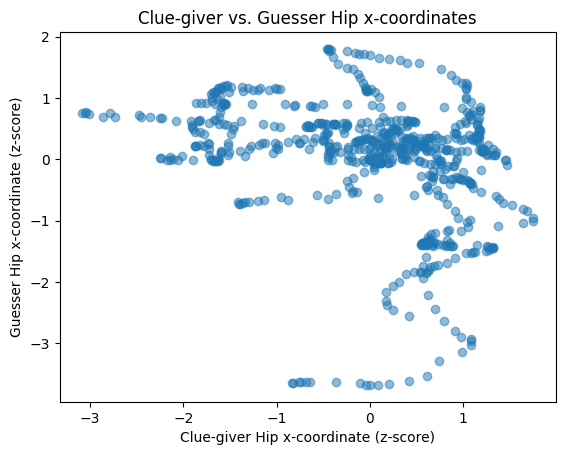

In [6]:
# Scatter plot of the two time series
plt.figure()
plt.scatter(both_hip_TS['Clue-giver'], both_hip_TS['Guesser'], alpha=0.5)
plt.xlabel('Clue-giver Hip x-coordinate (z-score)')
plt.ylabel('Guesser Hip x-coordinate (z-score)')
plt.title('Clue-giver vs. Guesser Hip x-coordinates')
plt.show()

Now let's quantify that association numerically, starting with the simplest possible statistic: the Pearson correlation, equivalent to `pyspi`'s `Covariance` SPI applied to two detrended, z-scored series.

In [7]:
# Compute covariance between the two time series
data = Data(np.stack([clue_giver_hip_TS, guesser_hip_TS]), detrend=True, normalise=True)
spi = Covariance()
cov_matrix = spi.multivariate(data)  # 2x2, diagonal is NaN by design
val = cov_matrix[0, 1]

print(f"Pearson correlation between Clue-giver and Guesser hip x-coordinates: {val}")

[1/2] Detrending time series in the dataset...
[2/2] Normalising (z-scoring) each time series in the dataset...

Pearson correlation between Clue-giver and Guesser hip x-coordinates: -0.29082533267389915


## Level 2: Sonnet subset, same time series pair

Level 2 keeps the same clue-giver/guesser hip pair, but replaces the single covariance statistic with `pyspi`'s `sonnet` subset — a curated set of 14 SPIs spanning basic, distance, causal, information-theoretic, spectral, wavelet, and miscellaneous statistic families. This gives a much richer picture of how the two time series relate to one another.

We compute the full `Calculator` on the same pair, then reshape the wide results table into long format (one row per SPI per direction) so it's easy to filter and plot:

In [8]:
# Sonnet subset
calc_level2 = Calculator(dataset=data, subset='sonnet')
calc_level2.compute()

# Convert statistics results to a readable table
table_level2 = calc_level2.table
table_level2.columns = table_level2.columns.to_flat_index()

table_level2 = table_level2.rename(columns='__'.join).assign(role_from = lambda x: x.index)
table_level2_long = table_level2.melt(id_vars='role_from', var_name='SPI__role_to', value_name='value')

# Reshape from wide to long, and add columns for person's role
table_level2_long["SPI"] = table_level2_long["SPI__role_to"].str.split("__").str[0]
table_level2_long["role_to"] = table_level2_long["SPI__role_to"].str.split("__").str[1]

table_level2_long = (table_level2_long.assign(role_from = lambda x: np.where(x.role_from == 'proc-0', 'Clue-giver', 'Guesser'),
                                    role_to = lambda x: np.where(x.role_to == 'proc-0', 'Clue-giver', 'Guesser'))
                    .drop(columns=['SPI__role_to'])
                    .query("role_from != role_to")
                    )

table_level2_long

Checking if optional dependencies exist...
Starting JVM with java class /Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/pyspi/lib/jidt/infodynamics.jar.
Loading configuration file: /Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/pyspi/sonnet_config.yaml
*** Importing module .statistics.basic
[0] Adding SPI .statistics.basic.Covariance(x,y,{'estimator': 'EmpiricalCovariance'})
Succesfully initialised SPI with identifier "cov_EmpiricalCovariance" and labels ['basic', 'unordered', 'linear', 'undirected', 'signed']
*** Importing module .statistics.distance


[1] Adding SPI .statistics.distance.DynamicTimeWarping(x,y,{'global_constraint': 'itakura'})
Succesfully initialised SPI with identifier "dtw_constraint-itakura" and labels ['unsigned', 'distance', 'temporal', 'undirected', 'nonlinear']
[2] Adding SPI .statistics.distance.Barycenter(x,y,{'mode': 'dtw', 'statistic': 'mean'})
Succesfully initialised SPI with identifier "bary_dtw_mean" and labels ['distance', 'signed', 'undirected', 'temporal', 'nonlinear']
*** Importing module .statistics.causal


No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


[3] Adding SPI .statistics.causal.AdditiveNoiseModel(x,y)...
Succesfully initialised SPI with identifier "anm" and labels ['unsigned', 'causal', 'unordered', 'linear', 'directed']
*** Importing module .statistics.infotheory
[4] Adding SPI .statistics.infotheory.DirectedInfo(x,y,{'estimator': 'gaussian'})
Succesfully initialised SPI with identifier "di_gaussian" and labels ['unsigned', 'infotheory', 'temporal', 'directed', 'linear']
[5] Adding SPI .statistics.infotheory.TransferEntropy(x,y,{'estimator': 'kraskov', 'prop_k': 4, 'auto_embed_method': 'MAX_CORR_AIS', 'k_search_max': 10, 'tau_search_max': 4, 'dyn_corr_excl': 'AUTO'})
Succesfully initialised SPI with identifier "te_kraskov_NN-4_DCE_k-max-10_tau-max-4" and labels ['unsigned', 'embedding', 'infotheory', 'temporal', 'directed', 'nonlinear']
[6] Adding SPI .statistics.infotheory.IntegratedInformation(x,y,{'phitype': 'star'})
Succesfully initialised SPI with identifier "phi_star_t-1_norm-0" and labels ['linear', 'unsigned', 'infot

Frequency minimum set to 0; overriding to 1e-5.


Succesfully initialised SPI with identifier "sgc_nonparametric_mean_fs-1_fmin-0_fmax-0-5" and labels ['unsigned', 'embedding', 'spectral', 'directed', 'lagged']
*** Importing module .statistics.wavelet
[11] Adding SPI .statistics.wavelet.PhaseSlopeIndex(x,y,{'fs': 1})
Succesfully initialised SPI with identifier "psi_wavelet_mean_fs-1_fmin-0_fmax-0-5_mean" and labels ['unsigned', 'wavelet', 'undirected']
*** Importing module .statistics.misc
[12] Adding SPI .statistics.misc.Cointegration(x,y,{'method': 'aeg', 'statistic': 'tstat', 'autolag': 'aic', 'maxlag': 10, 'trend': 'ct'})
Succesfully initialised SPI with identifier "coint_aeg_tstat_trend-ct_autolag-aic_maxlag-10" and labels ['misc', 'unsigned', 'temporal', 'undirected', 'nonlinear']
[13] Adding SPI .statistics.misc.PowerEnvelopeCorrelation(x,y,{'orth': False, 'log': False, 'absolute': False})
Succesfully initialised SPI with identifier "pec" and labels ['unsigned', 'misc', 'undirected']
14 SPI(s) were successfully initialised.



Processing [None: cohmag_multitaper_mean_fs-1_fmin-0_fmax-0-5]:  43%|████▎     | 6/14 [00:03<00:04,  1.97it/s]Mean of empty slice
Processing [None: sgc_nonparametric_mean_fs-1_fmin-0_fmax-0-5]:  43%|████▎     | 6/14 [00:03<00:04,  1.97it/s]Mean of empty slice
Processing [None: pec]: 100%|██████████| 14/14 [00:03<00:00,  3.76it/s]                                          



Calculation complete. Time taken: 3.7292s

SPI Computation Results Summary

Total number of SPIs attempted: 14
Number of SPIs successfully computed: 14 (100.00%)
------------------------------------------------------------
Category       | Count | Percentage
------------------------------------------------------------
Successful     |    14 | 100.00%
NaNs           |     0 |   0.00%
Partial NaNs   |     0 |   0.00%
------------------------------------------------------------


,role_from,value,SPI,role_to
1,Guesser,-0.290825,cov_EmpiricalCovariance,Clue-giver
2,Clue-giver,-0.290825,cov_EmpiricalCovariance,Guesser
5,Guesser,32.626012,dtw_constraint-itakura,Clue-giver
6,Clue-giver,32.626012,dtw_constraint-itakura,Guesser
9,Guesser,0.112570,bary_dtw_mean,Clue-giver
10,Clue-giver,0.112570,bary_dtw_mean,Guesser
13,Guesser,1.245747,anm,Clue-giver
14,Clue-giver,0.836276,anm,Guesser
17,Guesser,3.464970,di_gaussian,Clue-giver
18,Clue-giver,4.712265,di_gaussian,Guesser


Passing the long-format table into R lets us visualize all 14 SPI values side-by-side, faceted by statistic:

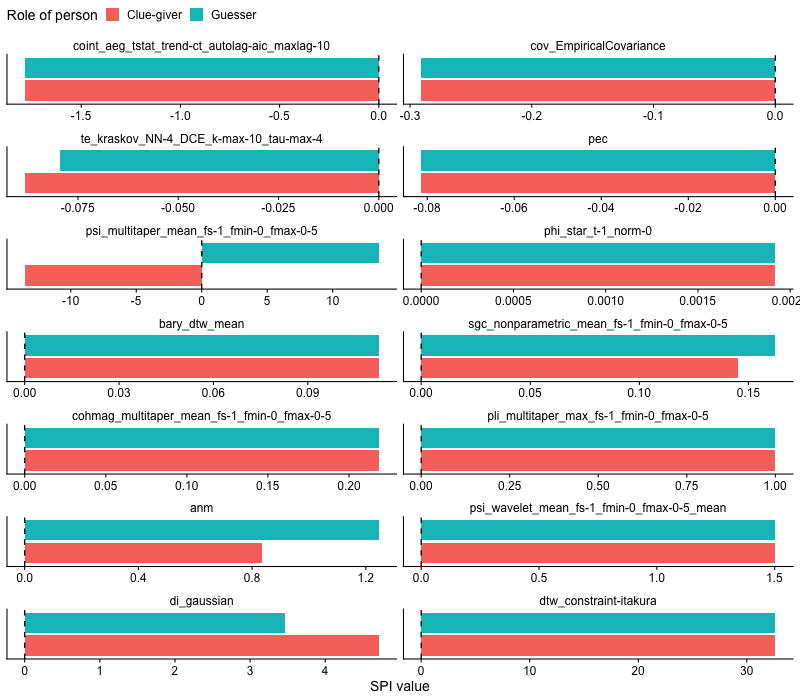

In [9]:
%%R -i table_level2_long -w 800 -h 700

library(ggplot2)
library(tidyverse)

table_level2_long %>%
    # filter(SPI == 'cov_EmpiricalCovariance') %>%
    mutate(SPI = fct_reorder(SPI, value, .fun = median)) %>% 
    ggplot(data=., mapping=aes(x=role_from, y=value, fill=role_from)) +
    geom_bar(stat="identity", position=position_dodge()) +
    coord_flip() +
    geom_hline(yintercept=0, linetype="dashed", color = "black") +
    facet_wrap(~SPI, scales='free', strip.position = 'top', ncol=2) +
    ylab('SPI value') +
    labs(fill='Role of person') +
    theme(axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          axis.title.y = element_blank(),
          strip.background = element_blank(),
          legend.position = 'top')


## Level 3: Fast SPI subset, same pair of time series (hip x-position in clue-giver vs. guesser)

Level 3 repeats the same hip-sway pair once more, this time with the `fast` SPI subset — a smaller set of computationally cheap statistics, useful when scaling up to many time-series pairs or nodes.

In [ ]:
# Fast subset
calc_level3 = Calculator(dataset=data, subset='fast')
calc_level3.compute()

# Convert statistics results to a readable table
table_level3 = calc_level3.table
table_level3.columns = table_level3.columns.to_flat_index()

table_level3 = table_level3.rename(columns='__'.join).assign(role_from = lambda x: x.index)
table_level3_long = table_level3.melt(id_vars='role_from', var_name='SPI__role_to', value_name='value')

# Reshape from wide to long, and add columns for person's role
table_level3_long["SPI"] = table_level3_long["SPI__role_to"].str.split("__").str[0]
table_level3_long["role_to"] = table_level3_long["SPI__role_to"].str.split("__").str[1]

table_level3_long = (table_level3_long.assign(role_from = lambda x: np.where(x.role_from == 'proc-0', 'Clue-giver', 'Guesser'),
                                    role_to = lambda x: np.where(x.role_to == 'proc-0', 'Clue-giver', 'Guesser'))
                    .drop(columns=['SPI__role_to'])
                    .query("role_from != role_to")
                    )

In [11]:
table_level3_long.head()

,role_from,value,SPI,role_to
1,Guesser,-0.290825,cov_EmpiricalCovariance,Clue-giver
2,Clue-giver,-0.290825,cov_EmpiricalCovariance,Guesser
5,Guesser,-0.280825,cov_GraphicalLasso,Clue-giver
6,Clue-giver,-0.280825,cov_GraphicalLasso,Guesser
9,Guesser,-0.000000,cov_GraphicalLassoCV,Clue-giver


## Level 4: 'Sonnet' subset across four distinct time-series pairs

Having looked at a single pair with two different SPI subsets, Level 4 keeps the `sonnet` subset fixed and instead expands the number of time-series pairs — moving from hips alone to four distinct body-part comparisons.

In addition to the average left/right x-position (hip sway), we will now expand our scope to an additional three time-series examples from the same dataset:

1. `Y_RIGHT_WRIST`: y-coordinates of the right wrist in the clue-giver versus guesser, capturing gesture kinematics
2. `Y_NOSE`: y-coordinates of the nose in the clue-giver versus guesser, capturing head movement/nodding
3. `X_RIGHT_SHOULDER` + `X_LEFT_SHOULDER`: as with the hips, the average x-coordinate between left/right shoulders in clue-giver versus guesser

In [12]:
# Y_RIGHT_WRIST
clue_giver_right_wrist_TS = clue_giver_body_TS["Y_RIGHT_WRIST"]
guesser_right_wrist_TS = guesser_body_TS["Y_RIGHT_WRIST"]

# Y_NOSE 
clue_giver_nose_TS = clue_giver_body_TS["Y_NOSE"]
guesser_nose_TS = guesser_body_TS["Y_NOSE"]

# Average of left and right shoulder x-coordinates
clue_giver_shoulder_TS = (clue_giver_body_TS["X_LEFT_SHOULDER"] + clue_giver_body_TS["X_RIGHT_SHOULDER"]) / 2
guesser_shoulder_TS = (guesser_body_TS["X_LEFT_SHOULDER"] + guesser_body_TS["X_RIGHT_SHOULDER"]) / 2


As with the hip data, let's manually apply linear detrending + z-scoring just for visualization purposes:

<Figure size 640x480 with 0 Axes>

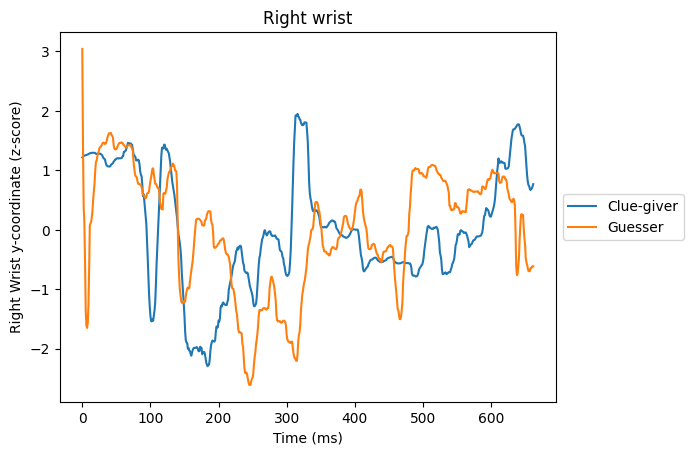

<Figure size 640x480 with 0 Axes>

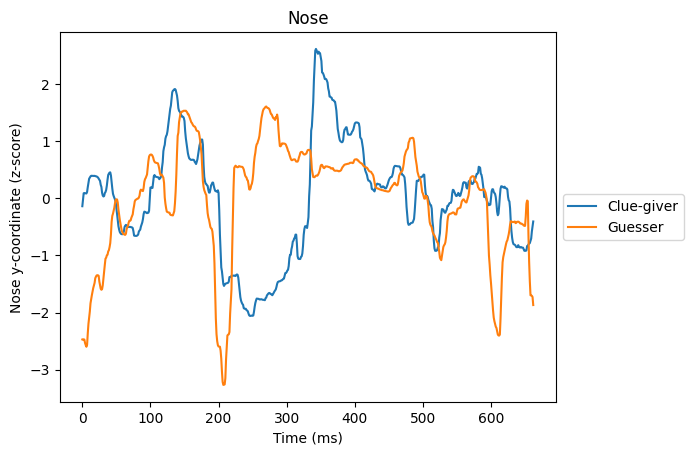

<Figure size 640x480 with 0 Axes>

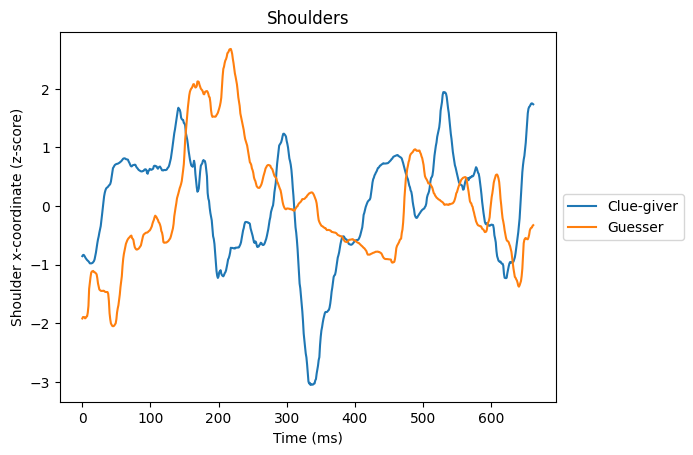

In [13]:
def plot_time_series(ts1, ts2, title='Time Series Plot', yaxis_label='Value'):

    # Manually apply linear detrending and z-scoring to the time series, 
    # only for visualization purposes (this is applied separately in pyspi)
    ts1_detrend = scipy.stats.zscore(scipy.signal.detrend(ts1))
    ts2_detrend = scipy.stats.zscore(scipy.signal.detrend(ts2))

    # Combine the two time series into a two-column array
    both_TS = pd.DataFrame({
        'Clue-giver': ts1_detrend,
        'Guesser': ts2_detrend
    })

    # Plot the time series
    plt.figure()
    both_TS.plot()

    ax = plt.gca()
    ax.legend(labels=['Clue-giver', 'Guesser'], loc='center left', bbox_to_anchor=(1, 0.5))
    plt.xlabel('Time (ms)')
    plt.ylabel(yaxis_label)
    plt.title(title)
    plt.show()

# Y_RIGHT_WRIST
plot_time_series(clue_giver_right_wrist_TS, guesser_right_wrist_TS, title='Right wrist', yaxis_label='Right Wrist y-coordinate (z-score)')

# Y_NOSE
plot_time_series(clue_giver_nose_TS, guesser_nose_TS, title='Nose', yaxis_label='Nose y-coordinate (z-score)')

# Average of left and right shoulder x-coordinates
plot_time_series(clue_giver_shoulder_TS, guesser_shoulder_TS, title='Shoulders', yaxis_label='Shoulder x-coordinate (z-score)')

Now let's compute the `sonnet` SPI subset for each of the four body-part pairs, using a small helper function so we don't repeat the reshaping logic four times over:

In [ ]:
# Apply the 'sonnet' SPI subset to each pair of time series
def apply_pyspi_subset(ts1, ts2):
    data = Data(np.stack([ts1, ts2]), detrend=True, normalise=True)
    calc = Calculator(dataset=data, subset='sonnet')
    calc.compute()
    table = calc.table
    table.columns = table.columns.to_flat_index()
    table = table.rename(columns='__'.join).assign(role_from = lambda x: x.index)
    table_long = table.melt(id_vars='role_from', var_name='SPI__role_to', value_name='value')
    table_long["SPI"] = table_long["SPI__role_to"].str.split("__").str[0]
    table_long["role_to"] = table_long["SPI__role_to"].str.split("__").str[1]
    table_long = (table_long.assign(role_from = lambda x: np.where(x.role_from == 'proc-0', 'Clue-giver', 'Guesser'),
                                    role_to = lambda x: np.where(x.role_to == 'proc-0', 'Clue-giver', 'Guesser'))
                    .drop(columns=['SPI__role_to'])
                    .query("role_from != role_to")
                    )
    return table_long

# Average of left and right hip x-coordinates
hip_pyspi_results = apply_pyspi_subset(clue_giver_hip_TS, guesser_hip_TS).assign(body_part='Hips')

# Y_RIGHT_WRIST
right_wrist_pyspi_results = apply_pyspi_subset(clue_giver_right_wrist_TS, guesser_right_wrist_TS).assign(body_part='Right Wrist')

# Y_NOSE
nose_pyspi_results = apply_pyspi_subset(clue_giver_nose_TS, guesser_nose_TS).assign(body_part='Nose')

# Average of left and right shoulder x-coordinates
shoulder_pyspi_results = apply_pyspi_subset(clue_giver_shoulder_TS, guesser_shoulder_TS).assign(body_part='Shoulders')

Combining all four body-part results into one long-format table lets us compare SPI values across body parts directly, faceted by statistic:

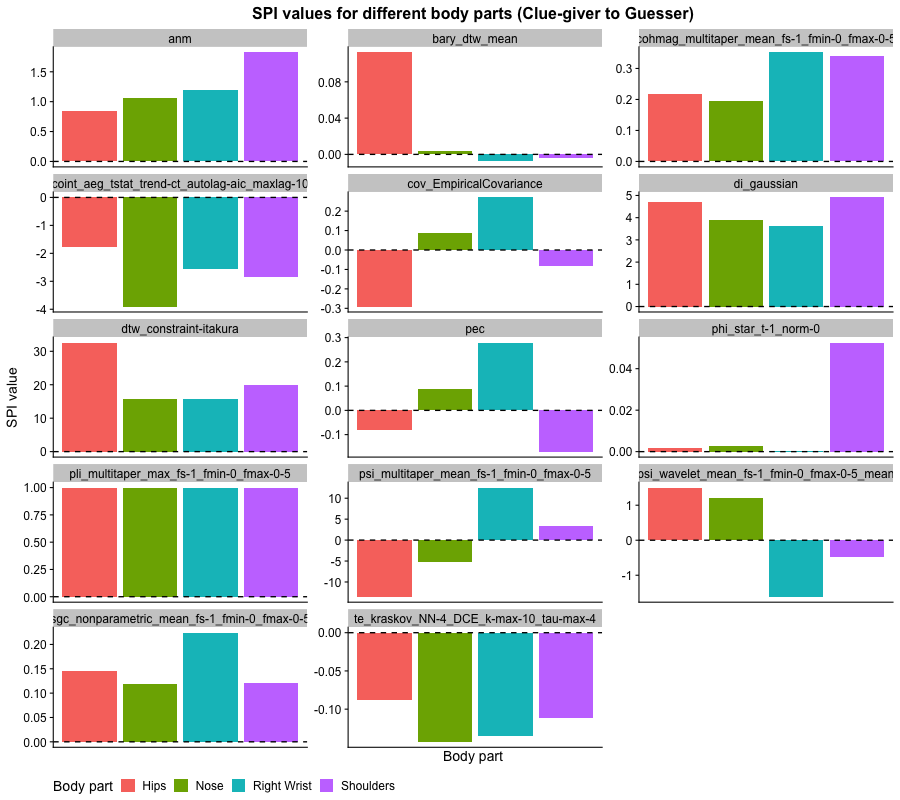

In [15]:
%%R -i hip_pyspi_results,right_wrist_pyspi_results,nose_pyspi_results,shoulder_pyspi_results -w 900 -h 800

# Combine all body part results into a single data frame
combined_results <- rbind(hip_pyspi_results, right_wrist_pyspi_results, nose_pyspi_results, shoulder_pyspi_results)

combined_results %>%
    filter(role_from == 'Clue-giver') %>%
    ggplot(data=., mapping=aes(x=body_part, y=value, fill=body_part)) +
    geom_bar(stat="identity", position=position_dodge()) +
    facet_wrap('SPI', scales='free', ncol=3)  +
    ylab('SPI value') +
    xlab('Body part') +
    labs(fill= 'Body part') +
    geom_hline(yintercept=0, linetype="dashed", color = "black") +
    ggtitle('SPI values for different body parts (Clue-giver to Guesser)') +
    theme(axis.text.x = element_blank(),
          axis.ticks.x = element_blank(),
          plot.title = element_text(hjust = 0.5),
          legend.position = 'bottom')

## Level 5: Sonnet subset across a 4-node hip + nose system

So far every SPI has been computed on an isolated *pair* of time series. Level 5 instead builds a single 4-node multivariate dataset — both hips and both noses — and computes the `sonnet` subset once across all node pairs, giving a full 4x4 interaction matrix for each statistic.

In [16]:
# Combine all body part results into a single numpy array
hip_and_nose_combined_TS = np.stack([clue_giver_hip_TS, guesser_hip_TS, 
                                     clue_giver_nose_TS, guesser_nose_TS], axis=0)

# Convert to pyspi Data object, applying linear detrending and z-scoring to each time series
hip_and_nose_combined_data = Data(hip_and_nose_combined_TS, detrend=True, normalise=True, dim_order='ps')

# Apply the 'sonnet' SPI subset to the combined data
calc_hip_and_nose_combined = Calculator(dataset=hip_and_nose_combined_data, subset='sonnet')
calc_hip_and_nose_combined.compute()

[1/2] Detrending time series in the dataset...
[2/2] Normalising (z-scoring) each time series in the dataset...

Loading configuration file: /Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/pyspi/sonnet_config.yaml
*** Importing module .statistics.basic
[0] Adding SPI .statistics.basic.Covariance(x,y,{'estimator': 'EmpiricalCovariance'})
Succesfully initialised SPI with identifier "cov_EmpiricalCovariance" and labels ['basic', 'unordered', 'linear', 'undirected', 'signed']
*** Importing module .statistics.distance
[1] Adding SPI .statistics.distance.DynamicTimeWarping(x,y,{'global_constraint': 'itakura'})
Succesfully initialised SPI with identifier "dtw_constraint-itakura" and labels ['unsigned', 'distance', 'temporal', 'undirected', 'nonlinear']
[2] Adding SPI .statistics.distance.Barycenter(x,y,{'mode': 'dtw', 'statistic': 'mean'})
Succesfully initialised SPI with identifier "bary_dtw_mean" and labels ['distance', 'signed', 'undirected', 'temporal', 'nonlinear']

Frequency minimum set to 0; overriding to 1e-5.


Succesfully initialised SPI with identifier "sgc_nonparametric_mean_fs-1_fmin-0_fmax-0-5" and labels ['unsigned', 'embedding', 'spectral', 'directed', 'lagged']
*** Importing module .statistics.wavelet
[11] Adding SPI .statistics.wavelet.PhaseSlopeIndex(x,y,{'fs': 1})
Succesfully initialised SPI with identifier "psi_wavelet_mean_fs-1_fmin-0_fmax-0-5_mean" and labels ['unsigned', 'wavelet', 'undirected']
*** Importing module .statistics.misc
[12] Adding SPI .statistics.misc.Cointegration(x,y,{'method': 'aeg', 'statistic': 'tstat', 'autolag': 'aic', 'maxlag': 10, 'trend': 'ct'})
Succesfully initialised SPI with identifier "coint_aeg_tstat_trend-ct_autolag-aic_maxlag-10" and labels ['misc', 'unsigned', 'temporal', 'undirected', 'nonlinear']
[13] Adding SPI .statistics.misc.PowerEnvelopeCorrelation(x,y,{'orth': False, 'log': False, 'absolute': False})
Succesfully initialised SPI with identifier "pec" and labels ['unsigned', 'misc', 'undirected']
14 SPI(s) were successfully initialised.



Processing [None: cohmag_multitaper_mean_fs-1_fmin-0_fmax-0-5]:  43%|████▎     | 6/14 [00:05<00:10,  1.37s/it]Mean of empty slice
Processing [None: sgc_nonparametric_mean_fs-1_fmin-0_fmax-0-5]:  43%|████▎     | 6/14 [00:05<00:10,  1.37s/it]Mean of empty slice
Processing [None: pec]: 100%|██████████| 14/14 [00:05<00:00,  2.39it/s]                                           



Calculation complete. Time taken: 5.8566s

SPI Computation Results Summary

Total number of SPIs attempted: 14
Number of SPIs successfully computed: 14 (100.00%)
------------------------------------------------------------
Category       | Count | Percentage
------------------------------------------------------------
Successful     |    14 | 100.00%
NaNs           |     0 |   0.00%
Partial NaNs   |     0 |   0.00%
------------------------------------------------------------


Let's check which SPIs were computed:

In [17]:
calc_hip_and_nose_combined.spis.keys()

dict_keys(['cov_EmpiricalCovariance', 'dtw_constraint-itakura', 'bary_dtw_mean', 'anm', 'di_gaussian', 'te_kraskov_NN-4_DCE_k-max-10_tau-max-4', 'phi_star_t-1_norm-0', 'cohmag_multitaper_mean_fs-1_fmin-0_fmax-0-5', 'psi_multitaper_mean_fs-1_fmin-0_fmax-0-5', 'pli_multitaper_max_fs-1_fmin-0_fmax-0-5', 'sgc_nonparametric_mean_fs-1_fmin-0_fmax-0-5', 'psi_wavelet_mean_fs-1_fmin-0_fmax-0-5_mean', 'coint_aeg_tstat_trend-ct_autolag-aic_maxlag-10', 'pec'])

For a 4-node system it's easier to read each SPI as a 4x4 interaction matrix rather than a bar chart. The helper below plots one matrix per SPI, using a diverging colormap when the statistic can go negative and a sequential one otherwise:

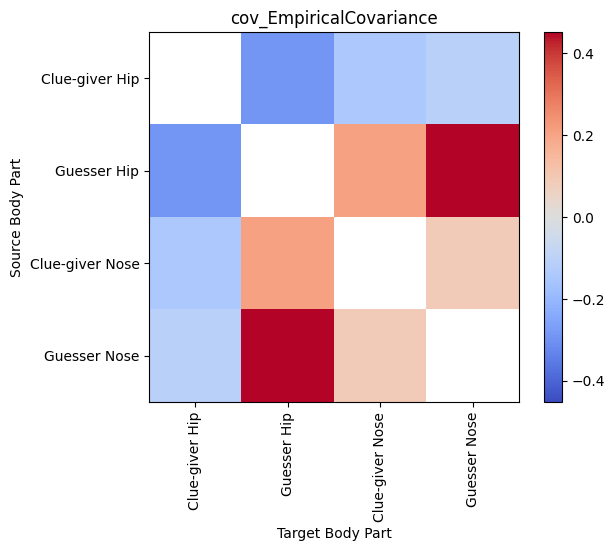

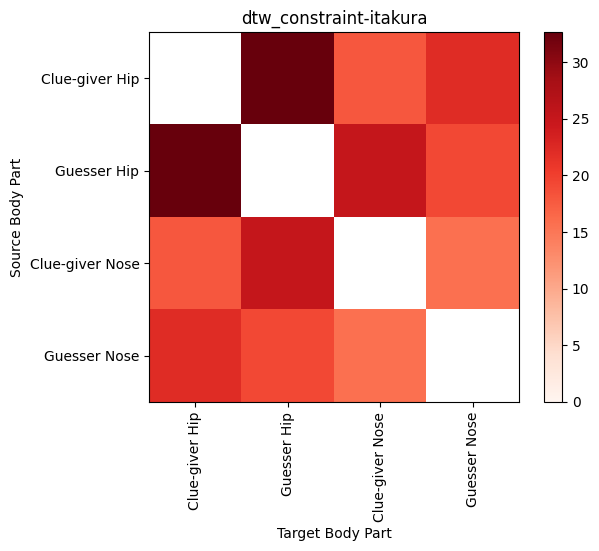

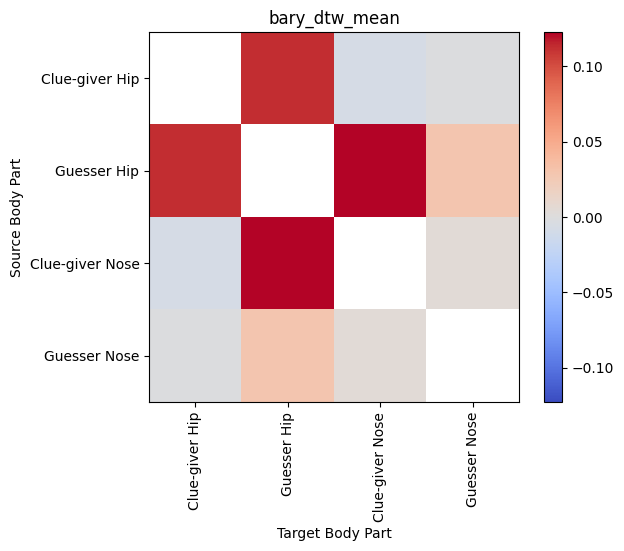

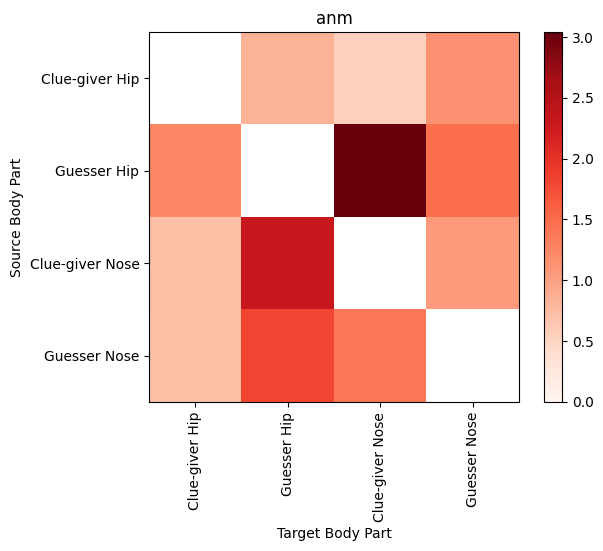

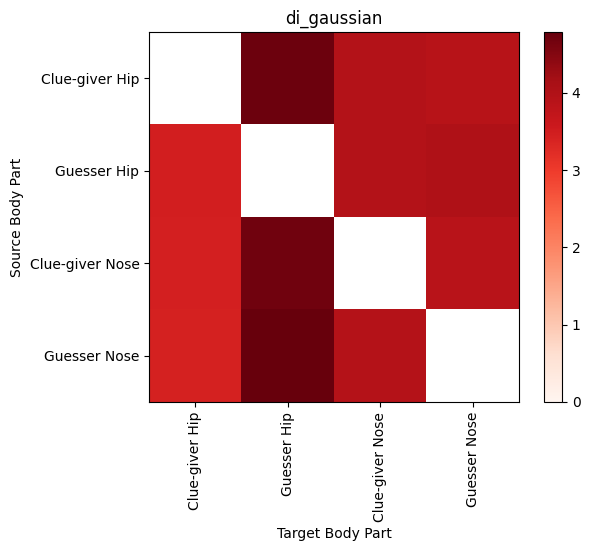

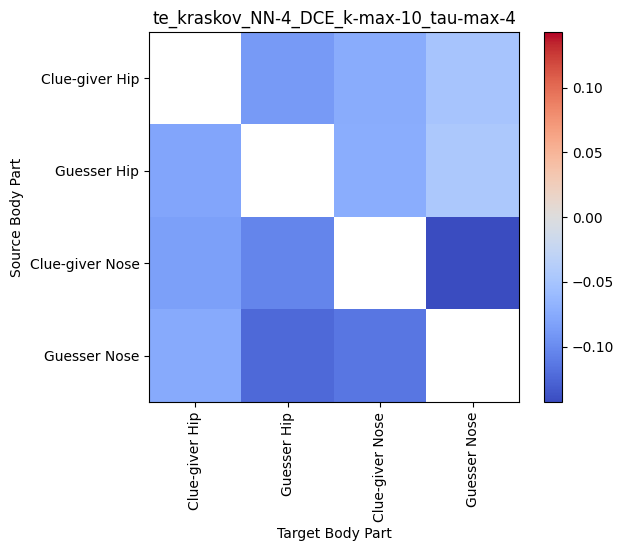

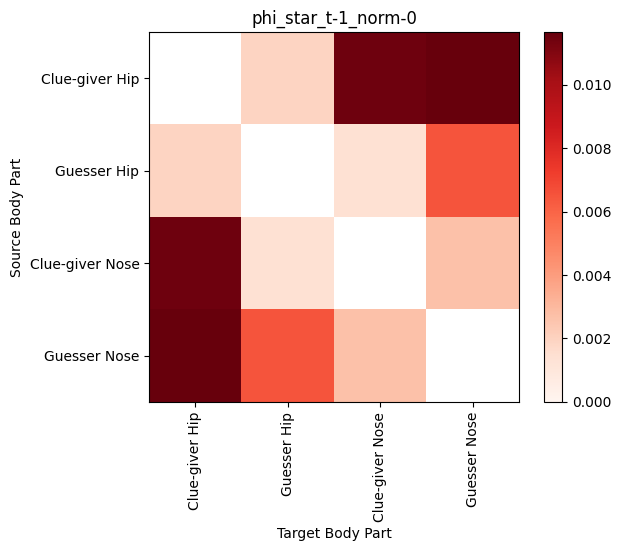

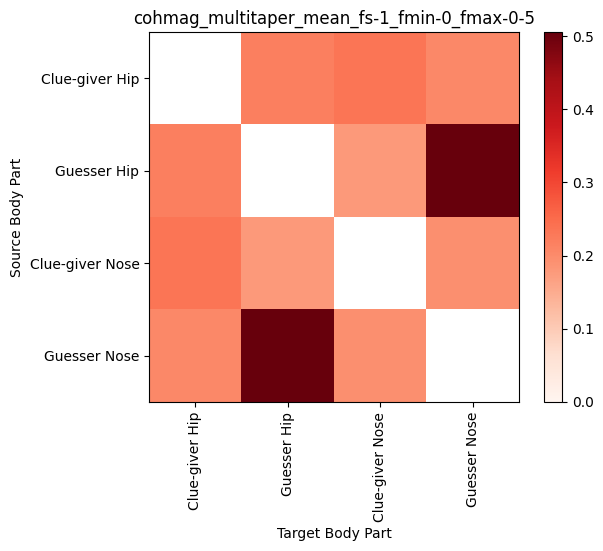

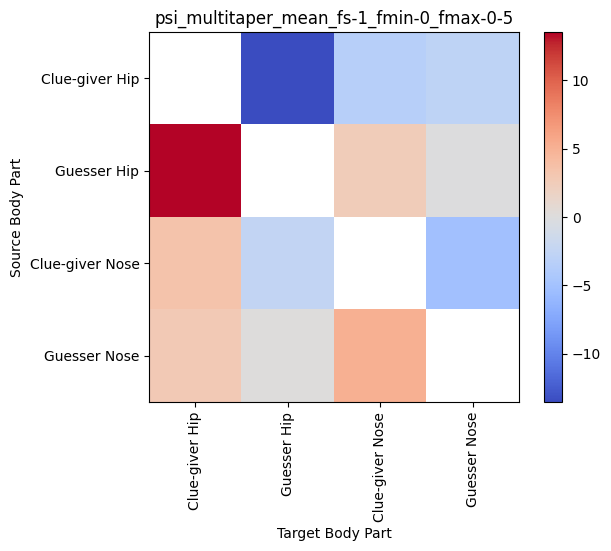

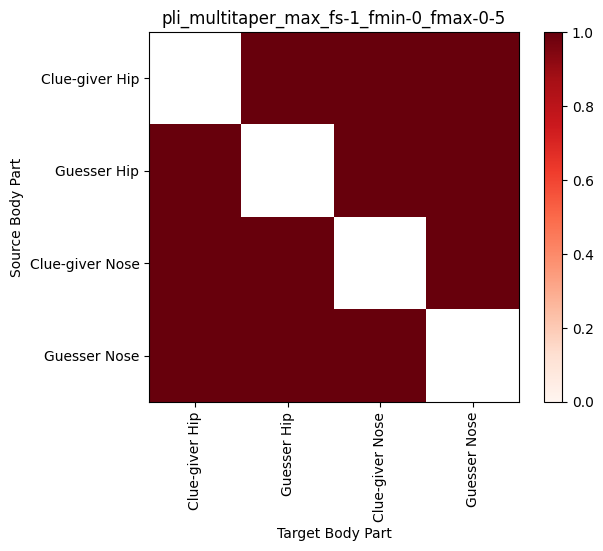

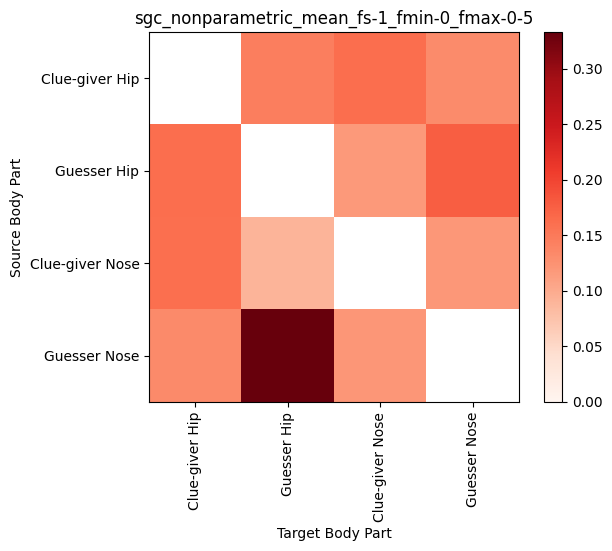

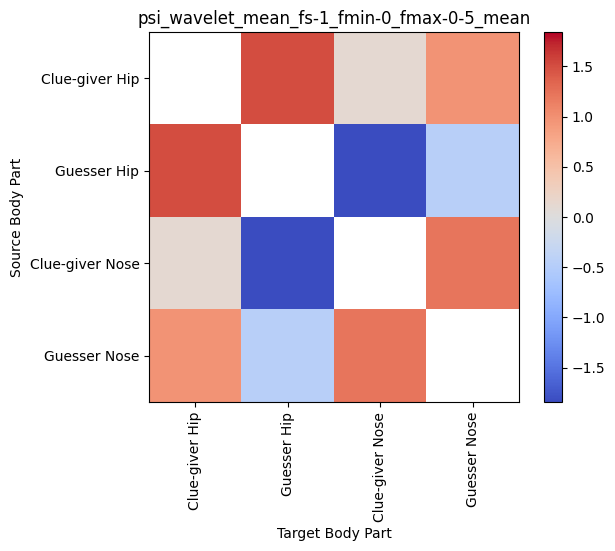

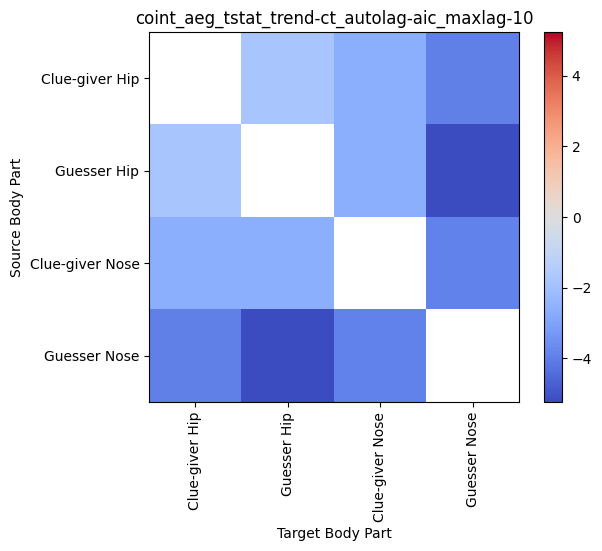

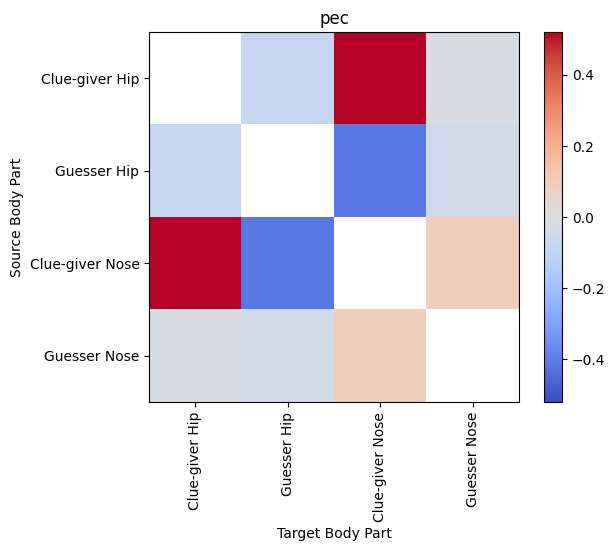

In [18]:
def plot_mpi(S,identifier,labels,ax=None):
    """ Plot a given matrix of pairwise interactions, annotating the process labels and identifier
    """
    if ax is None:
        _, ax = plt.subplots()
    plt.sca(ax)

    # Use a diverging cmap if our statistic goes negative (and a sequential cmap otherwise)
    if np.nanmin(S) < 0.:
        maxabsval = max(abs(np.nanmin(S)),abs(np.nanmax(S)))
        norm = colors.Normalize(vmin=-maxabsval, vmax=maxabsval)
        plt.imshow(S,cmap='coolwarm',norm=norm)
    else:
        plt.imshow(S,cmap='Reds',vmin=0)

    plt.xticks(ticks=range(len(labels)),labels=labels,rotation=90)
    plt.yticks(ticks=range(len(labels)),labels=labels)
    plt.xlabel('Target Body Part')
    plt.ylabel('Source Body Part')
    plt.title(identifier)
    plt.colorbar()

# Time-series labels
ts_labels = ['Clue-giver Hip', 'Guesser Hip',
             'Clue-giver Nose', 'Guesser Nose']

# Iterate over SPIs and plot the 4x4 result matrix
for identifier in calc_hip_and_nose_combined.spis.keys():
    S = calc_hip_and_nose_combined.table[identifier]
    plot_mpi(S, identifier, ts_labels)

# Plot this dataframe
# plot_mpi(S = calc_hip_and_nose_combined.table["cov_EmpiricalCovariance"], identifier = "cov_EmpiricalCovariance", labels = ts_labels)

## An example from real brain-data analysis

To show that the same `pyspi` workflow generalizes beyond motion-tracking data, we close with a quick example on real resting-state fMRI data: computing the `sonnet` SPI subset between homotopic (left/right hemisphere) pairs of brain regions from the Desikan-Killiany parcellation.

Here's what that parcellation atlas looks like:

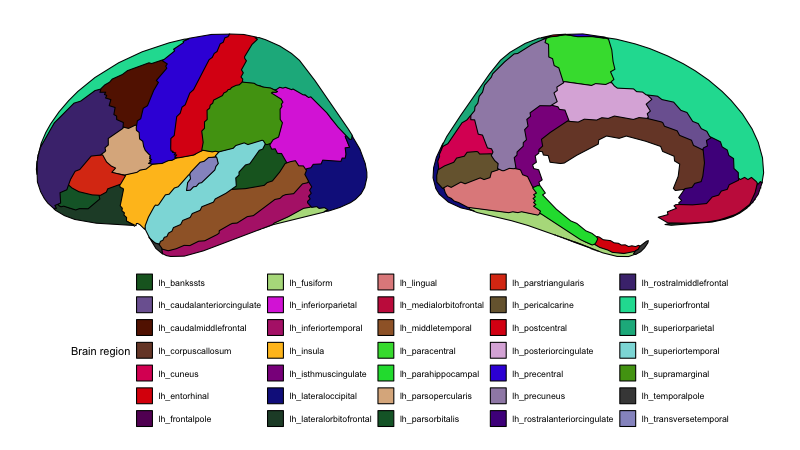

In [19]:
%%R -w 800 -h 450

ggplot() +
  geom_brain(atlas = dk(), hemi = 'left', view = c('medial', 'lateral'), show.legend = TRUE,
             linewidth = 0.5, colour = 'black') +
  theme_void() +
  labs(fill='Brain region') +
  theme(legend.position = "bottom") 

For each base region in the parcellation, we pull out its left- and right-hemisphere time series, build a `pyspi` `Data` object from the pair, and compute the `sonnet` subset — looping over all base regions and collecting the results into one long-format table:

In [ ]:
rsfMRI_TS = pd.read_csv('HCP_298051_rsfMRI_DesikanKilliany_TS.csv')

# Create a new Calculator object
base_calc = Calculator(subset='sonnet')

# Read in brain regions
brain_region_lookup = pd.read_csv("Brain_Region_info.csv", index_col=False).reset_index(drop=True)
base_regions = list(set(brain_region_lookup.Base_Region.tolist()))

# Create list to store homotopic FC results for each base region
homotopic_FC_results_list = []

# Iterate over the base regions as the target regions
for this_region in base_regions:
    region_info_subset = brain_region_lookup.query("Base_Region == @this_region")
    left_region_name = region_info_subset.query("Hemisphere == 'Left'")["Brain_Region"].values[0]
    right_region_name = region_info_subset.query("Hemisphere == 'Right'")["Brain_Region"].values[0]

    # Extract the time series for the left and right regions
    left_region_TS = rsfMRI_TS[left_region_name].values
    right_region_TS = rsfMRI_TS[right_region_name].values

    base_region_data = Data(np.stack([left_region_TS, right_region_TS]), detrend=True, normalise=True, dim_order='ps')

    # Make a copy of the base Calculator object
    calc = deepcopy(base_calc)

    # Load the brain region pair data
    calc.load_dataset(base_region_data)

    # Compute SPIs
    calc.compute()

    # Get SPI results
    homotopic_FC_res = deepcopy(calc.table)
    homotopic_FC_res.columns = homotopic_FC_res.columns.to_flat_index()

    homotopic_FC_res = homotopic_FC_res.rename(columns='__'.join).assign(hemi_from = lambda x: x.index)
    homotopic_FC_res_long = homotopic_FC_res.melt(id_vars='hemi_from', var_name='SPI__hemi_to', value_name='value')

    # Reshape from wide to long, and add columns for hemisphere and base region
    homotopic_FC_res_long["SPI"] = homotopic_FC_res_long["SPI__hemi_to"].str.split("__").str[0]
    homotopic_FC_res_long["hemi_to"] = homotopic_FC_res_long["SPI__hemi_to"].str.split("__").str[1]

    homotopic_FC_res_long = (homotopic_FC_res_long.assign(hemi_from = lambda x: np.where(x.hemi_from == 'proc-0', 'L', 'R'),
                                        hemi_to = lambda x: np.where(x.hemi_to == 'proc-0', 'L', 'R'))
                        .drop(columns=['SPI__hemi_to'])
                        .query("hemi_from != hemi_to")
                        .assign(Base_Region = this_region)
                        )
    
    homotopic_FC_results_list.append(homotopic_FC_res_long)

# Concatenate all the results into a single DataFrame
all_homotopic_FC_results = pd.concat(homotopic_FC_results_list, ignore_index=True)

A peek at the resulting long-format table of homotopic SPI values:

In [21]:
all_homotopic_FC_results.head()

,hemi_from,value,SPI,hemi_to,Base_Region
0,R,0.666198,cov_EmpiricalCovariance,L,postcentral
1,L,0.666198,cov_EmpiricalCovariance,R,postcentral
2,R,16.140894,dtw_constraint-itakura,L,postcentral
3,L,16.140894,dtw_constraint-itakura,R,postcentral
4,R,-0.002844,bary_dtw_mean,L,postcentral


The standard method for examining homotopic connectivity would be the Pearson correlation coefficient (`cov_EmpiricalCovariance` in pyspi, since covariance with $z$-scored time series is the Pearson correlation).

Let's compare the behavior of the Pearson correlation coefficient with that of the power envelop correlation (`pec`; highly correlated) and the mean of the barycenter with dynamic time warping alignment (`bary_dtw_mean`; minimally correlated):

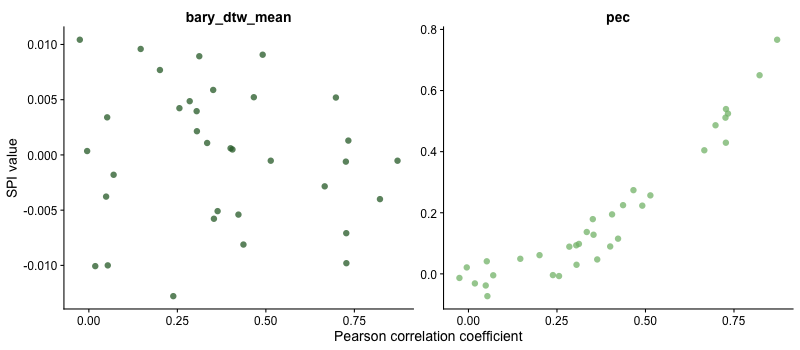

In [22]:
%%R -i all_homotopic_FC_results -w 800 -h 350

all_homotopic_FC_results %>%
    filter(SPI %in% c('cov_EmpiricalCovariance', 'pec', 'bary_dtw_mean') & hemi_from=='L') %>% 
    pivot_wider(names_from = SPI, values_from = value) %>%
    pivot_longer(cols=c('pec', 'bary_dtw_mean'), names_to = 'SPI_2', values_to = 'value') %>%
    ggplot(data=.,  mapping=aes(x=cov_EmpiricalCovariance, y=value, color=SPI_2)) +
    geom_point(alpha=0.75, stroke=0, size=3) +
    facet_wrap(~SPI_2, scales='free', ncol=2) +
    ylab('SPI value') +
    xlab('Pearson correlation coefficient') +
    scale_color_manual(values=c('pec'='#83BC7A', 'bary_dtw_mean'='#2D6932')) +
    theme(legend.position='none',
          strip.background = element_blank(),
          strip.text = element_text(size=14, face='bold'),
          axis.title = element_text(size=14))

We can visualize these three SPIs, all of which are undirected, projected onto the cortical surface to appreciate their spatial distribution:

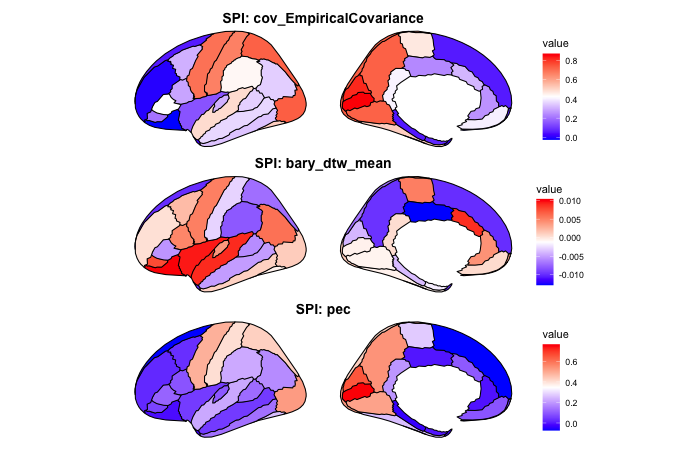

In [23]:
%%R -i all_homotopic_FC_results,brain_region_lookup -w 700 -h 450


df <- all_homotopic_FC_results %>%
    filter(SPI %in% c('cov_EmpiricalCovariance', 'pec', 'bary_dtw_mean') & hemi_from=='L') %>% 
    select(Base_Region, SPI, value) %>%
    left_join(brain_region_lookup %>% filter(Hemisphere=='Left'), by=c("Base_Region"="Base_Region")) %>%
    rename('label' = 'ggseg') %>%
    mutate(label = str_replace(label, 'ctx-lh-', 'lh_')) %>%
    left_join(as.data.frame(dk()), by=c("label"="label"), relationship = "many-to-many") 

# Use Desikan-Killiany atlas to visualize the results, removing the corpus callosum region for clarity
dk_atlas <- dk()
dk_atlas <- atlas_region_remove(dk_atlas, c("corpuscallosum"))

# Start list of brain plots
brain_plot_list <- list()

# Iterate over SPIs
for (spi in unique(df$SPI)) {
    df_spi <- df %>% filter(SPI == spi)
    
    p <- ggplot() +
        geom_brain(atlas = dk_atlas, mapping=aes(fill=value), data = df_spi,
                hemi = 'left', view = c('medial', 'lateral'),
                linewidth = 0.5, colour = 'black') +
        ggtitle(paste("SPI:", spi)) +
        scale_fill_gradientn(colors=c('blue', 'white', 'red'), na.value = 'grey90') +
        theme_void() +
        theme(plot.title = element_text(hjust = 0.5, size=14, face='bold'))
    
    brain_plot_list[[spi]] <- p
}

# Combine the plots into a single figure using patchwork
wrap_plots(brain_plot_list, ncol=1)